In [ ]:
# imports
import okex
from tardis.lib import pandas_utils as pu
from tardis.day_sample_options import sample_day_options, SampleConfig
from tardis.pcp_metrics import compute_pcp_metrics
from tardis.process import compact
from tardis import pcp_metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import polars as pl

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

execute = False
execute = True

recreate_pcpb_data = False
#recreate_pcpb_data = True

In [2]:
# recreate the pcpb compacted data, or just read it in
if recreate_pcpb_data:
    compact('2026-01-01', '2026-03-13',['deribit','okex'],ref_syms=['BTCUSD','ETHUSD'],output_path='datasets/compacted.parquet',
    cols_needed = ['ts','mdy','exchange','ref_sym','fut_sym','strike','exp','rel_strike',
                    "amu_fwd_bp", "call_opt_spread_bp", "amu_bck_bp", "put_opt_spread_bp",
                    "tte", "index", "call_stale", "put_stale", "fut_mid_price",
                   ])
pcpb_polars = pl.read_parquet('datasets/compacted.parquet')

In [3]:
# static summary of the data

# --- input parameters ---
REL_STRIKE_MIN = 0.8
REL_STRIKE_MAX = 1.2
# ------------------------

def summarize_timeslice_option_coverage(df):
    if df is None or df.height == 0:
        return pd.DataFrame()

    # restrict to near-the-money options
    filter_expr = (
        (pl.col("rel_strike") >= REL_STRIKE_MIN)
        & (pl.col("rel_strike") <= REL_STRIKE_MAX)
    )
    df = df.filter(filter_expr)

    group_keys = ["ref_sym", "exchange", "ts"]
    per_ts_contracts = df.group_by(group_keys).agg(
        pl.len().alias("num_contracts_ts")
    )

    per_ts_unique_aggs = []
    per_ts_unique_aggs.append(pl.col("strike").n_unique().alias("num_strikes_ts"))
    per_ts_unique_aggs.append(pl.col('exp').n_unique().alias("num_expirations_ts"))
    per_ts_unique_aggs.append(pl.col("call_opt_spread_bp").mean().alias("call_spread_bp_ts"))
    per_ts_unique_aggs.append(pl.col("put_opt_spread_bp").mean().alias("put_spread_bp_ts"))
    per_ts_uniques = df.group_by(group_keys).agg(per_ts_unique_aggs)

    per_ts = per_ts_contracts.join(per_ts_uniques, on=group_keys, how="left")

    group_keys_no_ts = ["ref_sym", "exchange"]
    n_days = df.group_by(group_keys_no_ts).agg(pl.col("mdy").n_unique().alias("Num days in sample"))

    summary = (
        per_ts.group_by(group_keys_no_ts)
        .agg(
            [
                pl.col("num_contracts_ts").mean().alias("Avg num contracts"),
                pl.col("num_expirations_ts").mean().alias("Avg num expirations"),
                pl.col("num_strikes_ts").mean().alias("Avg num strikes"),
                pl.col("call_spread_bp_ts").mean().alias("Avg call spread (bp)"),
                pl.col("put_spread_bp_ts").mean().alias("Avg put spread (bp)"),
]
        )
        .join(n_days, on=group_keys_no_ts, how="left")
        .sort(group_keys_no_ts)
    )

    return summary.to_pandas()


summary_daily = None
summary_daily_t = None
summary_daily_t_display = None
summary_daily_png = None
if execute and pcpb_polars is not None:
    summary_daily = summarize_timeslice_option_coverage(pcpb_polars)
    summary_daily_rounded = summary_daily.copy()

    metric_cols = [
        "Avg num contracts",
        "Avg num expirations",
        "Avg num strikes",
        "Num days in sample",
    ]
    # add spread columns if present
    for col in ["Avg call spread (bp)", "Avg put spread (bp)"]:
        if col in summary_daily_rounded.columns:
            metric_cols.append(col)

    for c in metric_cols:
        summary_daily_rounded[c] = pd.to_numeric(summary_daily_rounded[c], errors="coerce").round(0).astype("Int64")

    summary_daily_t = summary_daily_rounded.set_index(["ref_sym", "exchange"]).T
    summary_daily_t.columns = summary_daily_t.columns.set_names([None, None])

    summary_daily_t_display = summary_daily_t.copy()
    summary_daily_t_display = summary_daily_t_display.map(
        lambda v: f"{int(v):,}" if pd.notna(v) else ""
    )

display(summary_daily_t_display)

if summary_daily_t_display is not None:
    output_dir = Path("publications")
    output_dir.mkdir(parents=True, exist_ok=True)
    summary_daily_png = output_dir / "summary_daily_option_coverage.png"

    n_rows, n_cols = summary_daily_t_display.shape
    fig_h = max(2.5, 0.55 * (n_rows + 1))
    fig_w = max(8, 2.1 * (n_cols + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    tbl = ax.table(
        cellText=summary_daily_t_display.values,
        rowLabels=summary_daily_t_display.index.tolist(),
        colLabels=[f"{a} | {b}" for a, b in summary_daily_t_display.columns],
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.0, 1.2)

    plt.tight_layout()
    plt.savefig(summary_daily_png, dpi=220, bbox_inches="tight")
    plt.close(fig)

summary_daily_png


BTCUSD       ETHUSD     
                     deribit okex deribit okex
Avg num contracts        113   49      81   21
Avg num expirations        7    4       7    3
Avg num strikes           28   22      21   13
Avg call spread (bp)      32   20      49  137
Avg put spread (bp)       49   34      78   57
Num days in sample        73   72      73   72

PosixPath('publications/summary_daily_option_coverage.png')

In [4]:
# mark up with amu related stuff
def mark_up_pcpb_polars(df):
    # expects a polars DataFrame
    return df.with_columns([
        (pl.col("amu_fwd_bp") + pl.col("call_opt_spread_bp")).alias("fwd_call"),
        (pl.col("amu_fwd_bp") + pl.col("put_opt_spread_bp")).alias("fwd_put"),
        (pl.col("amu_bck_bp") + pl.col("call_opt_spread_bp")).alias("bck_call"),
        (pl.col("amu_bck_bp") + pl.col("put_opt_spread_bp")).alias("bck_put"),
    ])

pcpb = None
if execute and pcpb_polars is not None:
    pcpb = mark_up_pcpb_polars(pcpb_polars).to_pandas()
    pcpb = pcpb.loc[pcpb.ts > '2025-01-01']


In [ ]:
# calculate amu bps dataframe
def calculate_amu_bps(pcpb, max_bp_cutoff=100):
    fresh_idx =((~pcpb.call_stale)&(~pcpb.put_stale))|True
    pcpb_fresh = pcpb.loc[fresh_idx]

    join_call_ask_bp = float(pcpb_fresh.fwd_call.clip(lower=0, upper=max_bp_cutoff).mean())
    join_call_bid_bp = float(pcpb_fresh.bck_call.clip(lower=0, upper=max_bp_cutoff).mean())
    join_put_ask_bp = float(pcpb_fresh.bck_put.clip(lower=0, upper=max_bp_cutoff).mean())
    join_put_bid_bp = float(pcpb_fresh.fwd_put.clip(lower=0, upper=max_bp_cutoff).mean())
    join_call_ask_num = int((pcpb_fresh["fwd_call"] > 0).sum())
    join_call_bid_num = int((pcpb_fresh["bck_call"] > 0).sum())
    join_put_ask_num = int((pcpb_fresh["bck_put"] > 0).sum())
    join_put_bid_num = int((pcpb_fresh["fwd_put"] > 0).sum())
    amu_num = join_call_ask_num + join_call_bid_num + join_put_ask_num + join_put_bid_num

    weighted_sum = (
        join_call_ask_bp * join_call_ask_num
        + join_call_bid_bp * join_call_bid_num
        + join_put_ask_bp * join_put_ask_num
        + join_put_bid_bp * join_put_bid_num
    )

    weighted_avg = weighted_sum / amu_num if amu_num > 0 else np.nan
    return weighted_avg, amu_num, len(pcpb_fresh)


amu_summary = None
amu_summary_png = None
if execute and pcpb is not None:
    pcpb_filtered = (
        pcpb.loc[(pcpb["rel_strike"] >= REL_STRIKE_MIN) & (pcpb["rel_strike"] <= REL_STRIKE_MAX)]
        if "rel_strike" in pcpb.columns
        else pcpb
    )

    rows = []
    for (ref_sym, exchange), group in pcpb_filtered.groupby(["ref_sym", "exchange"]):
        amu_bps_val, amu_num_val, num_pairs_val = calculate_amu_bps(group)
        rows.append({
            "ref_sym": ref_sym,
            "exchange": exchange,
            "amu_bps": amu_bps_val,
            "amu_num": amu_num_val,
            "num_pairs": num_pairs_val,
        })
    amu_summary = pd.DataFrame(rows).set_index(["ref_sym", "exchange"])

    # publication PNG
    amu_display = (
        amu_summary[["amu_bps", "amu_num", "num_pairs"]]
        .rename(
            columns={
                "amu_bps": "AMU(bps)",
                "amu_num": "MU occurs",
                "num_pairs": "Num Observations",
            }
        )
        .rename_axis(index=["underlying", "exchange"])
    )
    amu_display = amu_display.copy()
    amu_display["AMU(bps)"] = amu_display["AMU(bps)"].map(
        lambda v: f"{v:.2f}" if pd.notna(v) else ""
    )
    for col in ["MU occurs", "Num Observations"]:
        amu_display[col] = amu_display[col].map(
            lambda v: f"{int(v):,}" if pd.notna(v) else ""
        )

    output_dir = Path("publications")
    output_dir.mkdir(parents=True, exist_ok=True)
    amu_summary_png = output_dir / "amu_summary.png"

    n_rows, n_cols = amu_display.shape
    fig_h = max(2.0, 0.55 * (n_rows + 1))
    fig_w = max(5, 2.1 * (n_cols + 2))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    tbl = ax.table(
        cellText=amu_display.values,
        rowLabels=[f"{a} | {b}" for a, b in amu_display.index],
        colLabels=amu_display.columns.tolist(),
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.0, 1.2)

    plt.tight_layout()
    plt.savefig(amu_summary_png, dpi=220, bbox_inches="tight")
    plt.close(fig)

print(amu_summary_png)
amu_summary


publications/amu_summary.png


amu_bps  amu_num  num_pairs
ref_sym exchange                              
BTCUSD  deribit   3.759100   587255    2317423
        okex      1.661176   165152    1018224
ETHUSD  deribit   5.978947   705279    1666474
        okex      6.184700   173137     435179

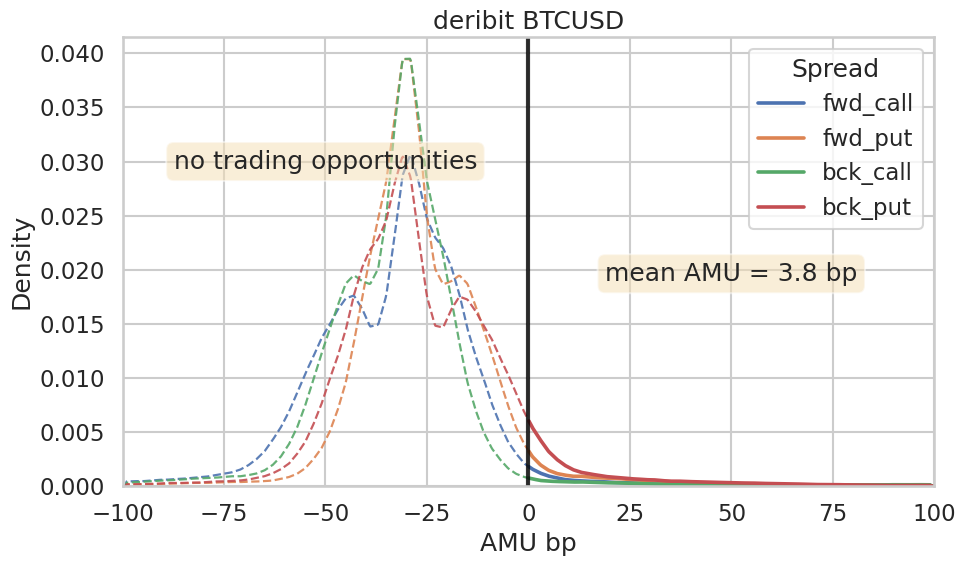

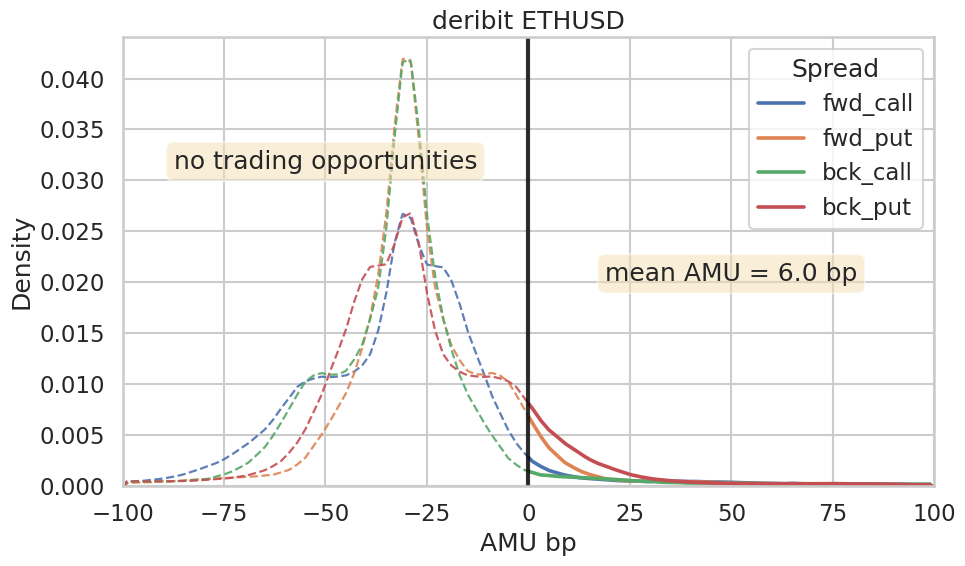

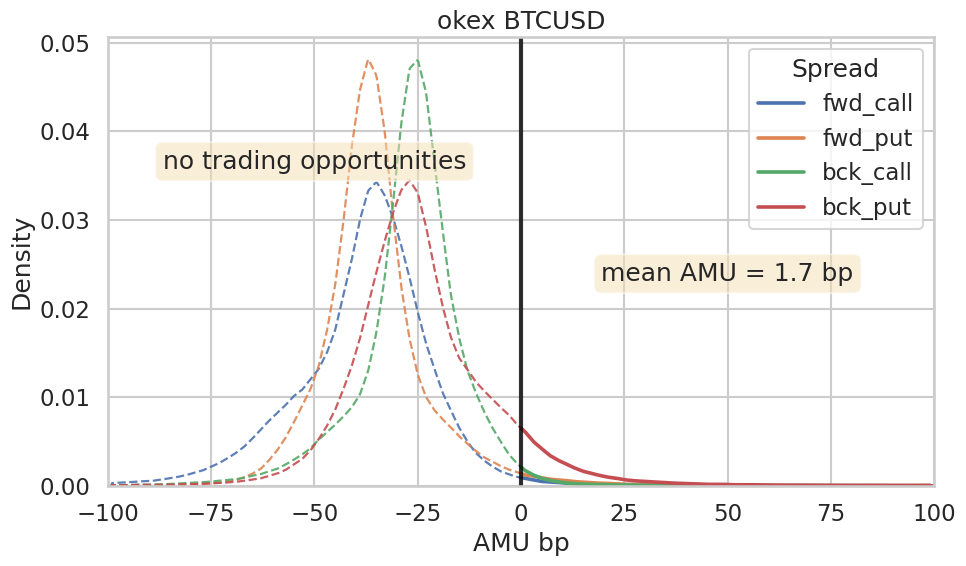

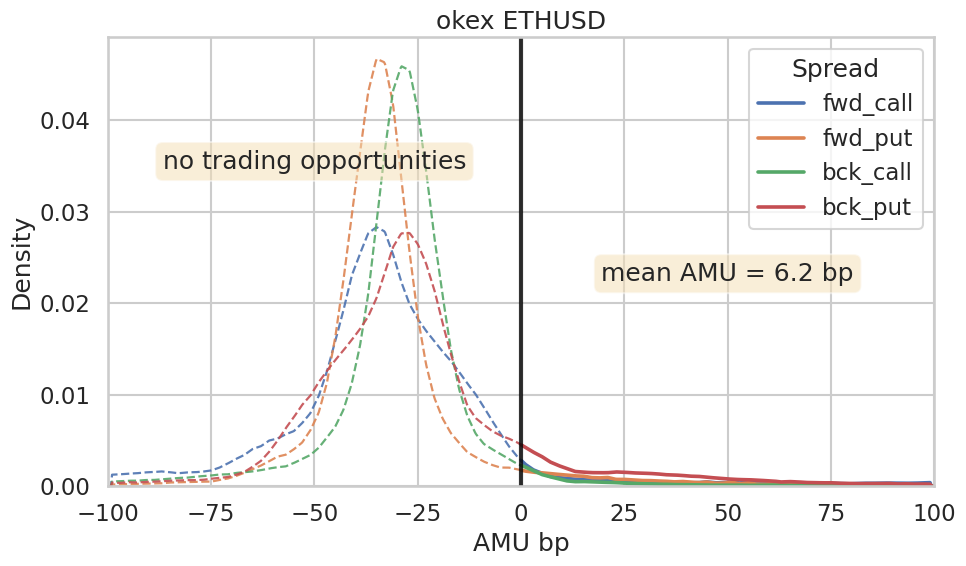

['publications/deribit_btcusd_4_spreads.png',
 'publications/deribit_ethusd_4_spreads.png',
 'publications/okex_btcusd_4_spreads.png',
 'publications/okex_ethusd_4_spreads.png']

In [6]:
def plot_4_spreads(
    pcpb,
    rng=100,
    smoothed=False,
    filename="okex_plot_4_spreads.png",
    title="OKEX AMU",
):
    sns.set_theme(style="whitegrid", context="talk")
    cols = ["fwd_call", "fwd_put", "bck_call", "bck_put"]
    colors = sns.color_palette("deep", n_colors=len(cols))
    fig, ax = plt.subplots(figsize=(10, 6))
    visible_max = 0.0

    for col, color in zip(cols, colors):
        vals = pd.to_numeric(pcpb[col], errors="coerce").to_numpy()
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        counts, edges = np.histogram(vals, bins=100, range=(-rng, rng), density=True)
        visible_max = max(visible_max, float(np.nanmax(counts)) if counts.size else 0.0)

        if smoothed:
            centers = 0.5 * (edges[:-1] + edges[1:])
            x_fine = np.linspace(-rng, rng, 800)
            y_fine = np.interp(x_fine, centers, counts, left=0.0, right=0.0)

            left_mask = x_fine < 0
            right_mask = x_fine >= 0

            ax.plot(
                x_fine[left_mask],
                y_fine[left_mask],
                color=color,
                linestyle="--",
                linewidth=1.6,
                alpha=0.9,
            )
            ax.plot(
                x_fine[right_mask],
                y_fine[right_mask],
                color=color,
                linestyle="-",
                linewidth=2.6,
                alpha=1.0,
                label=col,
            )
        else:
            sns.histplot(
                vals,
                bins=100,
                binrange=(-rng, rng),
                stat="density",
                element="step",
                fill=False,
                common_norm=False,
                ax=ax,
                label=col,
                linewidth=1.6,
                color=color,
            )

    ax.axvline(0, color="black", linestyle="-", linewidth=3.0, alpha=0.8)
    ax.set_xlim(-rng, rng)
    ax.set_ylim(0, visible_max * 1.05 if visible_max > 0 else 1.0)
    ax.set_xlabel("AMU bp")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(title="Spread")

    amu_text, _, _ = calculate_amu_bps(pcpb)
    ax.text(
        0.75,
        0.5,
        f"mean AMU = {amu_text:.1f} bp",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        va="top",
        ha="center",
    )

    ax.text(
        0.25,
        0.75,
        f"no trading opportunities",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        va="top",
        ha="center",
    )

    fig.tight_layout()
    fig.savefig(filename, dpi=220, bbox_inches="tight")
    return fig, ax


def _safe_name(x):
    return str(x).strip().lower().replace("-", "_").replace("/", "_")


fig = ax = None
plot_4_spreads_pngs = []
if execute and pcpb is not None:
    pcpb_plot = (
        pcpb.loc[(pcpb["rel_strike"] >= REL_STRIKE_MIN) & (pcpb["rel_strike"] <= REL_STRIKE_MAX)]
        if "rel_strike" in pcpb.columns
        else pcpb
    )

    output_dir = Path("publications")
    output_dir.mkdir(parents=True, exist_ok=True)

    for (exchange, ref_sym), pcpb_sub in pcpb_plot.groupby(["exchange", "ref_sym"]):
        if pcpb_sub.empty:
            continue

        png_path = output_dir / f"{_safe_name(exchange)}_{_safe_name(ref_sym)}_4_spreads.png"
        title = f"{exchange} {ref_sym}"
        fig, ax = plot_4_spreads(
            pcpb_sub,
            smoothed=True,
            filename=str(png_path),
            title=title,
        )
        plt.show()
        plt.close(fig)
        plot_4_spreads_pngs.append(str(png_path))

plot_4_spreads_pngs

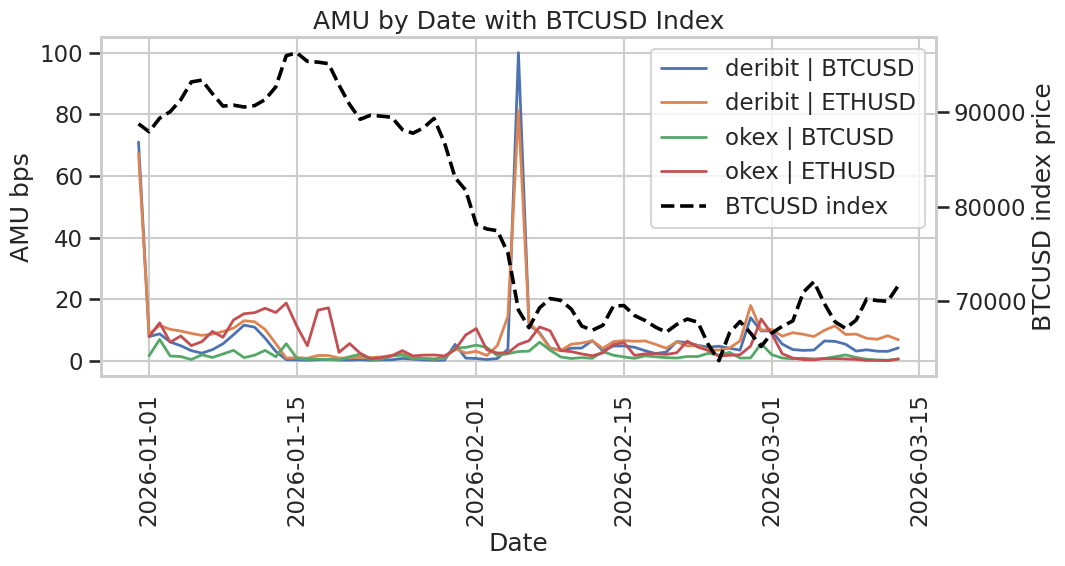

In [7]:
# plot AMU by date
def plot_amu_bps_by_date(
    pcpb,
    max_bp_cutoff=100,
    filename="publications/multi_exchange_amu_bps_by_date.png",
    title="AMU by date (all exchange/ref_sym)",
):
    pcpb_plot = (
        pcpb.loc[(pcpb["rel_strike"] >= REL_STRIKE_MIN) & (pcpb["rel_strike"] <= REL_STRIKE_MAX)]
        if "rel_strike" in pcpb.columns
        else pcpb
    ).copy()

    pcpb_plot["market"] = pcpb_plot["exchange"].astype(str) + " | " + pcpb_plot["ref_sym"].astype(str)

    daily_amu_bps = (
        pcpb_plot.groupby(["mdy", "exchange", "ref_sym", "market"], sort=True)
        .apply(
            lambda g: pd.Series(
                calculate_amu_bps(g, max_bp_cutoff=max_bp_cutoff),
                index=["amu_bps", "num_amu", "num_pairs"],
            )
        )
        .reset_index()
        .sort_values(["market", "mdy"])
    )

    btc_daily_index = (
        pcpb_plot.loc[pcpb_plot["ref_sym"] == "BTCUSD", ["mdy", "index"]]
        .groupby("mdy", sort=True)["index"]
        .mean()
        .reset_index()
    )

    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=(11, 6))

    sns.lineplot(
        data=daily_amu_bps,
        x="mdy",
        y="amu_bps",
        hue="market",
        linewidth=2.0,
        marker=None,
        ax=ax,
    )

    ax2 = ax.twinx()
    sns.lineplot(
        data=btc_daily_index,
        x="mdy",
        y="index",
        color="black",
        linewidth=2.6,
        linestyle="--",
        ax=ax2,
        label="BTCUSD index",
    )
    ax2.grid(False)
    ax2.set_ylabel("BTCUSD index price")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="best", title="")
    if ax2.legend_ is not None:
        ax2.legend_.remove()

    ax.set_xlabel("Date")
    ax.set_ylabel("AMU bps")
    ax.set_title(title)
    ax.tick_params(axis="x", labelrotation=90)

    fig.tight_layout()
    fig.savefig(filename, dpi=220, bbox_inches="tight")

    return daily_amu_bps, btc_daily_index, fig, (ax, ax2)


daily_amu_bps = btc_daily_index = daily_fig = daily_axes = None
if execute and pcpb is not None:
    daily_amu_bps, btc_daily_index, daily_fig, daily_axes = plot_amu_bps_by_date(
        pcpb,
        filename="publications/multi_exchange_amu_bps_by_date.png",
        title="AMU by Date with BTCUSD Index",
    )
    plt.show()

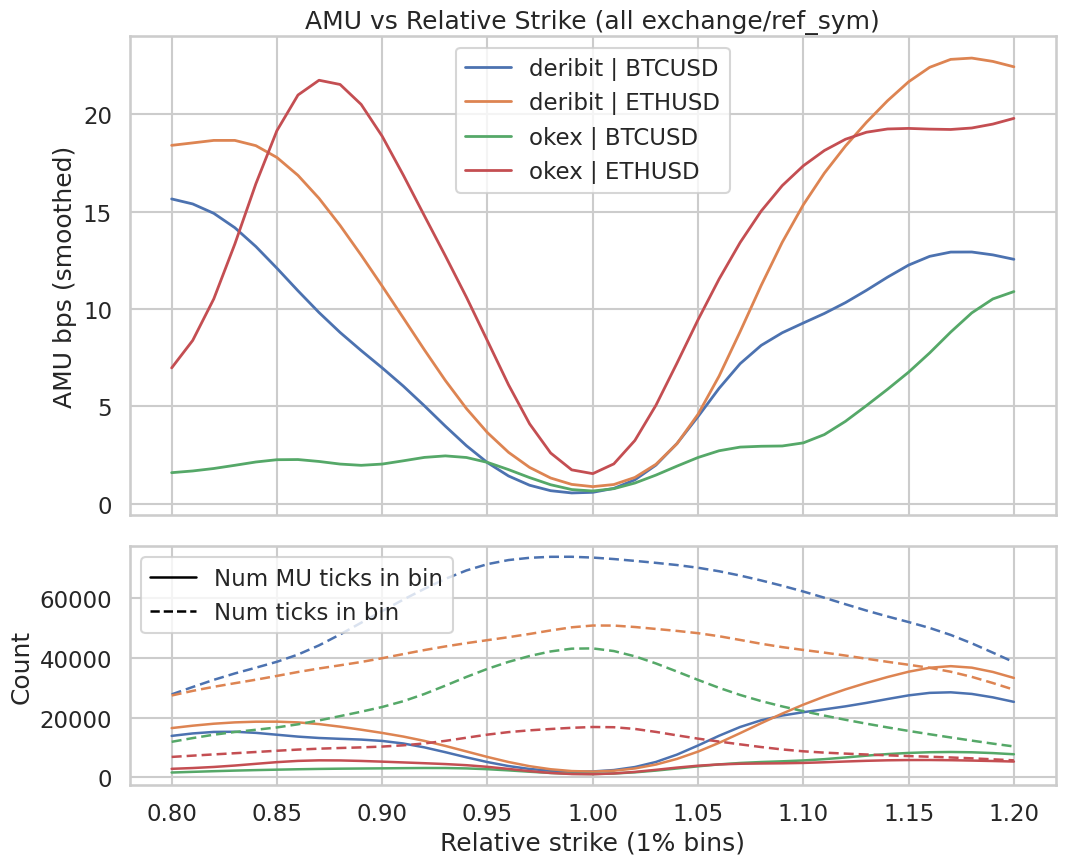

In [14]:
# plot amu by rel strike
def _gaussian_kernel_smooth(x, y, bandwidth=0.02):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid]
    y_valid = y[valid]
    if x_valid.size == 0:
        return out

    for i, x0 in enumerate(x):
        if not np.isfinite(x0):
            continue
        weights = np.exp(-0.5 * ((x_valid - x0) / bandwidth) ** 2)
        wsum = weights.sum()
        if wsum > 0:
            out[i] = np.dot(weights, y_valid) / wsum
    return out


def plot_amu_bps_by_rel_strike(
    pcpb,
    max_bp_cutoff=100,
    rel_strike_from=0.3,
    rel_strike_to=3.0,
    filename="publications/multi_exchange_amu_bps_by_rel_strike.png",
    title="AMU bps vs Relative Strike",
):
    bin_size = 0.01  # 1% bins

    pcpb_plot = (
        pcpb.dropna(subset=["exchange", "ref_sym", "rel_strike"])
.assign(
            rel_strike=lambda d: pd.to_numeric(d["rel_strike"], errors="coerce"),
            market=lambda d: d["exchange"].astype(str) + " | " + d["ref_sym"].astype(str),
        )
        .dropna(subset=["rel_strike"])
.loc[lambda d: d["rel_strike"].between(rel_strike_from, rel_strike_to)]
.assign(rel_strike_bin=lambda d: (d["rel_strike"] / bin_size).round() * bin_size)
    )

    curve_df = (
        pcpb_plot.groupby(["market", "rel_strike_bin"], sort=True)
.apply(
            lambda g: pd.Series(
                calculate_amu_bps(g, max_bp_cutoff=max_bp_cutoff),
                index=["amu_bps", "num_amu", "num_pairs"],
            )
        )
.reset_index()
.sort_values(["market", "rel_strike_bin"])
    )

    # Kernel-smooth AMU curve per market with Gaussian bandwidth 0.02.
    curve_df["amu_bps_smooth"] = np.nan
    for market, g in curve_df.groupby("market", sort=False):
        smoothed = _gaussian_kernel_smooth(
            g["rel_strike_bin"].to_numpy(),
            g["amu_bps"].to_numpy(),
            bandwidth=0.02,
        )
        curve_df.loc[g.index, "amu_bps_smooth"] = smoothed

    counts_df = curve_df[["market", "rel_strike_bin", "num_amu", "num_pairs"]].copy()
    counts_long = counts_df.melt(
        id_vars=["market", "rel_strike_bin"],
        value_vars=["num_amu", "num_pairs"],
        var_name="metric",
        value_name="count",
    )
    counts_long["metric"] = counts_long["metric"].map(
        {
            "num_amu": "Num MU ticks in bin",
            "num_pairs": "Num ticks in bin",
        }
    )

    # Kernel-smooth lower subplot counts per market/metric with same bandwidth.
    counts_long["count_smooth"] = np.nan
    for (market, metric), g in counts_long.groupby(["market", "metric"], sort=False):
        smoothed = _gaussian_kernel_smooth(
            g["rel_strike_bin"].to_numpy(),
            g["count"].to_numpy(),
            bandwidth=0.02,
        )
        counts_long.loc[g.index, "count_smooth"] = smoothed

    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=(11, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    sns.lineplot(
        data=curve_df,
        x="rel_strike_bin",
        y="amu_bps_smooth",
        hue="market",
        linewidth=2.0,
        palette="deep",
        ax=ax_top,
    )
    ax_top.set_ylabel("AMU bps (smoothed)")
    ax_top.set_title(title)
    ax_top.legend(title="", loc="best")

    sns.lineplot(
        data=counts_long,
        x="rel_strike_bin",
        y="count_smooth",
        hue="market",
        style="metric",
        linewidth=1.8,
        palette="deep",
        dashes={
            "Num MU ticks in bin": "",
            "Num ticks in bin": (4, 2),
        },
        legend=False,
        ax=ax_bottom,
    )
    ax_bottom.set_xlabel("Relative strike (1% bins)")
    ax_bottom.set_ylabel("Count")

    # Metric-only legend (style), omit market color mapping in lower subplot legend.
    from matplotlib.lines import Line2D

    metric_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label="Num MU ticks in bin"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.8, label="Num ticks in bin"),
    ]
    ax_bottom.legend(handles=metric_handles, title="")

    fig.tight_layout()
    fig.savefig(filename, dpi=220, bbox_inches="tight")

    return curve_df, counts_df, fig, (ax_top, ax_bottom)


amu_by_rel_strike = rel_counts = rel_fig = rel_axes = None
if execute and pcpb is not None:
    pcpb_plot = (
        pcpb.loc[(pcpb["rel_strike"] >= REL_STRIKE_MIN) & (pcpb["rel_strike"] <= REL_STRIKE_MAX)]
        if "rel_strike" in pcpb.columns
        else pcpb
    )
    amu_by_rel_strike, rel_counts, rel_fig, rel_axes = plot_amu_bps_by_rel_strike(
        pcpb_plot,
        filename="publications/multi_exchange_amu_bps_by_rel_strike.png",
        title="AMU vs Relative Strike (all exchange/ref_sym)",
    )
    plt.show()

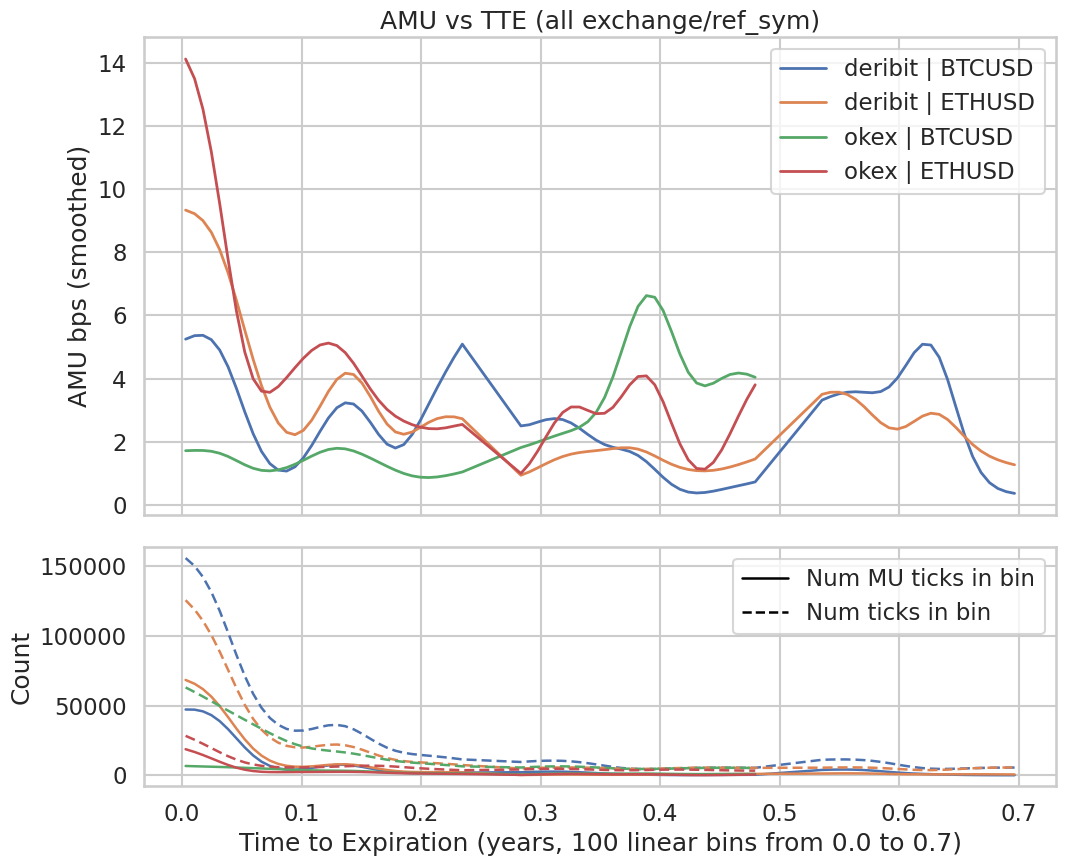

In [12]:
# plot AMU by tte
def _gaussian_kernel_smooth(x, y, bandwidth=0.02):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid]
    y_valid = y[valid]
    if x_valid.size == 0:
        return out

    for i, x0 in enumerate(x):
        if not np.isfinite(x0):
            continue
        weights = np.exp(-0.5 * ((x_valid - x0) / bandwidth) ** 2)
        wsum = weights.sum()
        if wsum > 0:
            out[i] = np.dot(weights, y_valid) / wsum
    return out


def plot_amu_bps_by_tte(
    pcpb,
    max_bp_cutoff=100,
    tte_from=0.0,
    tte_to=0.7,
    n_bins=100,
    filename="publications/multi_exchange_amu_bps_by_tte.png",
    title="AMU bps vs TTE",
):
    use_cols = ["exchange", "ref_sym", "tte", "fwd_call", "bck_call", "bck_put", "fwd_put"]
    tmp = (
        pcpb[use_cols]
        .assign(
            tte=lambda d: pd.to_numeric(d["tte"], errors="coerce"),
            market=lambda d: d["exchange"].astype(str) + " | " + d["ref_sym"].astype(str),
        )
        .dropna(subset=["tte", "market"])
        .loc[lambda d: d["tte"].between(tte_from, tte_to)]
        .copy()
    )

    tte_edges = np.linspace(tte_from, tte_to, n_bins + 1)
    tmp["tte_bin"] = pd.cut(tmp["tte"], bins=tte_edges, include_lowest=True)

    # Vectorized equivalent of calculate_amu_bps per group
    tmp["fwd_call_clip"] = tmp["fwd_call"].clip(lower=0, upper=max_bp_cutoff)
    tmp["bck_call_clip"] = tmp["bck_call"].clip(lower=0, upper=max_bp_cutoff)
    tmp["bck_put_clip"] = tmp["bck_put"].clip(lower=0, upper=max_bp_cutoff)
    tmp["fwd_put_clip"] = tmp["fwd_put"].clip(lower=0, upper=max_bp_cutoff)

    tmp["fwd_call_pos"] = (tmp["fwd_call"] > 0).astype(int)
    tmp["bck_call_pos"] = (tmp["bck_call"] > 0).astype(int)
    tmp["bck_put_pos"] = (tmp["bck_put"] > 0).astype(int)
    tmp["fwd_put_pos"] = (tmp["fwd_put"] > 0).astype(int)

    grouped = (
        tmp.groupby(["market", "tte_bin"], sort=True)
        .agg(
            fwd_call_bp=("fwd_call_clip", "mean"),
            bck_call_bp=("bck_call_clip", "mean"),
            bck_put_bp=("bck_put_clip", "mean"),
            fwd_put_bp=("fwd_put_clip", "mean"),
            fwd_call_num=("fwd_call_pos", "sum"),
            bck_call_num=("bck_call_pos", "sum"),
            bck_put_num=("bck_put_pos", "sum"),
            fwd_put_num=("fwd_put_pos", "sum"),
            num_pairs=("tte", "size"),
        )
        .reset_index()
    )

    grouped["num_amu"] = (
        grouped["fwd_call_num"]
        + grouped["bck_call_num"]
        + grouped["bck_put_num"]
        + grouped["fwd_put_num"]
    )
    grouped["weighted_sum"] = (
        grouped["fwd_call_bp"] * grouped["fwd_call_num"]
        + grouped["bck_call_bp"] * grouped["bck_call_num"]
        + grouped["bck_put_bp"] * grouped["bck_put_num"]
        + grouped["fwd_put_bp"] * grouped["fwd_put_num"]
    )
    grouped["amu_bps"] = grouped["weighted_sum"] / grouped["num_amu"].replace(0, np.nan)

    curve_df = grouped[["market", "tte_bin", "amu_bps", "num_amu", "num_pairs"]].copy()
    curve_df["tte_bin"] = curve_df["tte_bin"].astype("object")
    curve_df["tte_bin_center"] = curve_df["tte_bin"].map(
        lambda iv: iv.mid if isinstance(iv, pd.Interval) else np.nan
    )
    curve_df = curve_df.sort_values(["market", "tte_bin_center"])

    # Kernel-smooth AMU curve per market with Gaussian bandwidth 0.02.
    curve_df["amu_bps_smooth"] = np.nan
    for market, g in curve_df.groupby("market", sort=False):
        smoothed = _gaussian_kernel_smooth(
            g["tte_bin_center"].to_numpy(),
            g["amu_bps"].to_numpy(),
            bandwidth=0.02,
        )
        curve_df.loc[g.index, "amu_bps_smooth"] = smoothed

    counts_df = curve_df[["market", "tte_bin_center", "num_amu", "num_pairs"]].copy()
    counts_long = counts_df.melt(
        id_vars=["market", "tte_bin_center"],
        value_vars=["num_amu", "num_pairs"],
        var_name="metric",
        value_name="count",
    )
    counts_long["metric"] = counts_long["metric"].map(
        {
            "num_amu": "Num MU ticks in bin",
            "num_pairs": "Num ticks in bin",
        }
    )

    # Kernel-smooth lower subplot counts per market/metric with same bandwidth.
    counts_long["count_smooth"] = np.nan
    for (market, metric), g in counts_long.groupby(["market", "metric"], sort=False):
        smoothed = _gaussian_kernel_smooth(
            g["tte_bin_center"].to_numpy(),
            g["count"].to_numpy(),
            bandwidth=0.02,
        )
        counts_long.loc[g.index, "count_smooth"] = smoothed

    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=(11, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    sns.lineplot(
        data=curve_df,
        x="tte_bin_center",
        y="amu_bps_smooth",
        hue="market",
        linewidth=2.0,
        palette="deep",
        ax=ax_top,
    )
    ax_top.set_ylabel("AMU bps (smoothed)")
    ax_top.set_title(title)
    ax_top.legend(title="", loc="best")

    sns.lineplot(
        data=counts_long,
        x="tte_bin_center",
        y="count_smooth",
        hue="market",
        style="metric",
        linewidth=1.8,
        palette="deep",
        dashes={
            "Num MU ticks in bin": "",
            "Num ticks in bin": (4, 2),
        },
        legend=False,
        ax=ax_bottom,
    )
    ax_bottom.set_xlabel("Time to Expiration (years, 100 linear bins from 0.0 to 0.7)")
    ax_bottom.set_ylabel("Count")

    # Metric-only legend (style), omit market color mapping in lower subplot legend.
    from matplotlib.lines import Line2D

    metric_handles = [
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.8, label="Num MU ticks in bin"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.8, label="Num ticks in bin"),
    ]
    ax_bottom.legend(handles=metric_handles, title="")

    fig.tight_layout()
    fig.savefig(filename, dpi=220, bbox_inches="tight")

    return curve_df, counts_df, fig, (ax_top, ax_bottom)


amu_by_tte = tte_counts = tte_fig = tte_axes = None
if execute and pcpb is not None:
    pcpb_plot = (
        pcpb.loc[(pcpb["rel_strike"] >= REL_STRIKE_MIN) & (pcpb["rel_strike"] <= REL_STRIKE_MAX)]
        if "rel_strike" in pcpb.columns
        else pcpb
    )
    amu_by_tte, tte_counts, tte_fig, tte_axes = plot_amu_bps_by_tte(
        pcpb_plot,
        filename="publications/multi_exchange_amu_bps_by_tte.png",
        title="AMU vs TTE (all exchange/ref_sym)",
    )
    plt.show()